#### Simple MLP to test whether MBE regularization could "resolve conflict"


Given:
- Two input distributions $p_1$ and $p_2$
- Initial model parameters $\theta_0$
- Parameter shift vector $\Delta\theta$

We define:
\begin{align}
\text{Positive samples} &: \{(x, f_{\theta_0 + \Delta\theta}(x)) \mid x \sim p_1\} \\
\text{Negative samples} &: \{(x, f_{\theta_0 - \Delta\theta}(x)) \mid x \sim p_2\}
\end{align}

Where $f_{\theta}(x)$ represents the output of the model with parameters $\theta$ given input $x$. Note that two distributions should NOT be the same. 


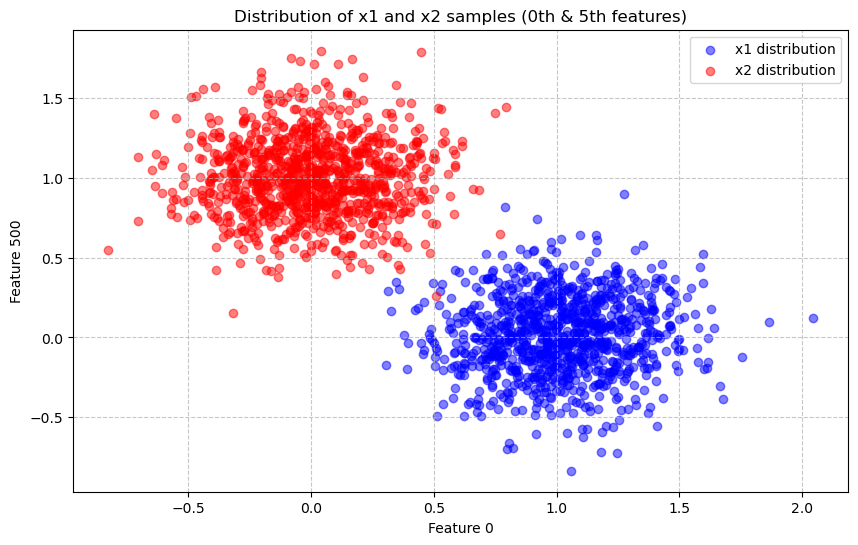

In [1]:
# initial distribution (p1 & p2)

# Define distributions p1 and p2
from src.ce_exp import sample_p1, sample_p2, plot_x1_x2

x1 = sample_p1(1000)
x2 = sample_p2(1000)
plot_x1_x2(x1, x2)


In [29]:
class GatedPhaseTransition:
    """
    Gated Phase Transition (GAPT) : https://arxiv.org/pdf/2505.08727
    with percentage-based thresholds.
    """
    def __init__(self, tau_plateau_m: float = 0.01, tau_plateau_a: float = 0.01, tau_spike: float = 0.1, 
                 p_m: int = 5, p_a: int = 5, min_a: float = 1e-5):
        """
        Args:
            tau_plateau: Relative threshold for detecting plateau (e.g., 0.01 = 1% improvement)
            tau_spike: Relative threshold for detecting spike (e.g., 0.1 = 10% degradation)
            p_m: Patience for main objective (steps without improvement)
            p_c: Patience for auxiliary objective (steps without improvement)
            min_a: Minimum value for auxiliary loss (to avoid division by zero)
        """
        self.tau_plateau_m = tau_plateau_m  # % improvement needed to avoid plateau
        self.tau_plateau_a = tau_plateau_a # % improvement needed to avoid plateau
        self.tau_spike = tau_spike      # % degradation that triggers phase switch
        self.p_m = p_m
        self.p_a = p_a

        self.phi = 1  # 1 for main phase, 2 for compression phase
        self.s_m = 0  # steps since improvement in main
        self.s_a = 0  # steps since improvement in auxiliary

        self.min_m = float('inf')
        self.min_a = float('inf')

    def _relative_gain(self, current_loss: torch.Tensor, min_loss: float) -> float:
        """Calculate percentage improvement (negative = degradation)"""
        if min_loss == float('inf') or abs(min_loss) < 1e-9:
            return 0.0
        current_val = current_loss.detach().item() if torch.is_tensor(current_loss) else current_loss
        return (min_loss - current_val) / max(abs(min_loss), 1e-6)

    def _weight_loss(self, main_loss: torch.Tensor, auxiliary_loss: torch.Tensor) -> torch.Tensor:
        """Weight the loss based on the phase"""
        if self.phi == 1:
            return main_loss
        elif self.phi == 2:
            # return main_loss + auxiliary_loss.clamp(min=self.min_a)

            # return main_loss + auxiliary_loss 

            # softness = 0.1  # controls sharpness
            # soft_aux = self.min_a + softness * torch.nn.functional.softplus(
            #     (auxiliary_loss - self.min_a) / softness
            # )
            # return main_loss + soft_aux

            scale = self.min_a / auxiliary_loss.detach().clamp(min=1e-8)
            return main_loss + auxiliary_loss * scale.clamp(max=1.0)

        return main_loss # fallback
    
    def step(self, main_loss: torch.Tensor, auxiliary_loss: torch.Tensor, 
             verbose: bool = False) -> torch.Tensor:
        """
        Update phase based on loss dynamics.
        
        Returns:
             weighted_loss: Weighted loss tensor suitable for .backward()
        """
        main_val = main_loss.detach().item()
        aux_val = auxiliary_loss.detach().item()

        if not (torch.isfinite(main_loss) and torch.isfinite(auxiliary_loss)):
            print(f"WARNING: Non-finite loss detected! main={main_val}, aux={aux_val}")
            return main_loss  # Fallback to main loss only

        gain_m = self._relative_gain(main_loss, self.min_m)
        gain_a = self._relative_gain(auxiliary_loss, self.min_a)
        
        self.min_m = min(self.min_m, main_val)
        self.min_a = min(self.min_a, aux_val)

        prev_phi = self.phi

        if self.phi == 1:  # Main objective phase
            if gain_m > self.tau_plateau_m: 
                self.s_m = 0
            else: 
                self.s_m += 1
            
            if self.s_m >= self.p_m:
                self.s_m = 0
                print(f"  [GAPT] Main loss plateaued for {self.p_m} steps, switch to [Compression] phase")
                self.phi = 2

        elif self.phi == 2:  # Main + Auxiliary phase
            if gain_m < -self.tau_spike:  
                if verbose:
                    print(f"  [GAPT] Main loss spiked: {-gain_m*100:.2f}% > {self.tau_spike*100:.2f}%, switch to [Memorization] phase")
                self.s_a = 0
                self.phi = 1
            else:
                if gain_a > self.tau_plateau_a:  
                    self.s_a = 0
                else: 
                    self.s_a += 1
                
                if self.s_a >= self.p_a:
                    if verbose:
                        print(f"  [GAPT] Auxiliary loss plateaued for {self.p_a} steps, switch to [Memorization] phase")
                    self.s_a = 0
                    self.phi = 1
                    
        
        if verbose and prev_phi != self.phi:
            print(f"  [GAPT] Phase transition: {prev_phi} → {self.phi}")
            print(f"         main_loss={main_val:.4f}, aux_loss={aux_val:.4f}")

        return self._weight_loss(main_loss, auxiliary_loss)

In [36]:
from src.ce_exp import * 

# Hyper-parameters 
# ------------------------------------------------------------
in_dim, hidden_dim, out_dim = 10, 20, 10 
data_size = 1000 
load_init = True
load_shift = True
exp_name = "exp_b2"
mod = "mix"
switch_phase = True

# Model initialization 
# ------------------------------------------------------------
mlp = SimpleModel(in_dim, hidden_dim, out_dim) # can we store a 'fixed' initial param, and load it every time we run experiment? 
INIT_PARAMS_PATH = 'initial_mlp_params.pt'
if load_init: 
    mlp.load_state_dict(torch.load(INIT_PARAMS_PATH))  # Load fixed parameters
else: 
    torch.save(mlp.state_dict(), INIT_PARAMS_PATH)
    
# Load Original Parameters for comparison purpose
# ------------------------------------------------------------
mlp_original = SimpleModel(in_dim, hidden_dim, out_dim)
mlp_original.load_state_dict(torch.load(INIT_PARAMS_PATH))

# Build 'Conflicting' dataset
# ------------------------------------------------------------
PARAM_SHIFT_PATH = "param_shift.pkl"
if load_shift: 
    param_shift = load_param_shift(PARAM_SHIFT_PATH)
else: 
    param_shift = None 
trainset, valset, param_shift = build_dataset(500, 100, mlp, in_dim, param_shift)


# Different Learning approaches 
# ------------------------------------------------------------
# (a). Train with P samples, then N samples 
# Initialize optimizer
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)
epochs = 1000
batch_size = 32
train_accumulation_steps = batch_size // 1
val_interval = 10
val_steps = 10

# GAPT
# ------------------------------------------------------------
# from src.gapt import GatedPhaseTransition
gapt = GatedPhaseTransition(p_m=125, p_a=75, tau_spike=0.1)
# ------------------------------------------------------------


# Train with positive samples first, then negative samples
# print("Training with positive samples first, then negative samples")
print("Training with positive samples")

loss_record = defaultdict(list)
frames = [] 

# Positive samples training
for epoch in range(epochs):
    group_name = decide_group_name(epoch, epochs, mod="positive")
    if epoch % val_interval == 0: 
        val_loss, similarity_metrics = validate(mlp, mlp_original, param_shift, valset, val_steps)
        for name, value in val_loss.items(): 
            loss_record[name].append(value.item())
        for name, value in similarity_metrics.items(): 
            loss_record[name].append(value)
        log_str = build_log_str(epoch, epochs, mod, val_loss, similarity_metrics)
        print(log_str)            
        frame, specialized = neuron_specialization_frame(mlp, trainset, batch_size, group_name, epoch)
        frames.append(frame)
            
    for accum_step in range(train_accumulation_steps): 
        x_batch, y_batch = get_batch(trainset, group_name)
        optimizer.zero_grad()
        loss_dict = mlp.compute_loss(x_batch, y_batch)
        # loss = gapt.step(loss_dict['l1'], 8 * loss_dict['mbe'], verbose=True)
        # loss = loss_dict["l1"]
        # loss = loss_dict["l1"] + loss_dict["mbe"].clamp(min=0.5)

        softness = 0.1  # controls sharpness
        soft_aux = loss_dict['mbe'].clamp(min=0.01) + softness * torch.nn.functional.softplus(
            (loss_dict['mbe'] - loss_dict['mbe'].clamp(min=0.01)) / softness
        )
        loss = loss_dict['l1'] + soft_aux

        loss.backward()
        

    optimizer.step()
    mlp.zero_grad(set_to_none=True)


- Dataset constructed with 600 positive & negative samples
Training with positive samples
 Epoch 1/1000,  | l1 positive loss: 0.5017 | mbe positive loss: 0.1052 | param shift similarity positive : 0.0000 | rep similarity positive : 0.5471 | l1 negative loss: 0.4503 | mbe negative loss: 0.2295 | param shift similarity negative : 0.0000 | rep similarity negative : 0.6111
 Epoch 11/1000,  | l1 positive loss: 0.2444 | mbe positive loss: 0.0150 | param shift similarity positive : 0.1322 | rep similarity positive : 0.5123 | l1 negative loss: 0.5178 | mbe negative loss: 0.2941 | param shift similarity negative : -0.1322 | rep similarity negative : 0.6109
 Epoch 21/1000,  | l1 positive loss: 0.2148 | mbe positive loss: 0.0098 | param shift similarity positive : 0.1542 | rep similarity positive : 0.5502 | l1 negative loss: 0.5330 | mbe negative loss: 0.3179 | param shift similarity negative : -0.1542 | rep similarity negative : 0.5390
 Epoch 31/1000,  | l1 positive loss: 0.2033 | mbe positive l

In [ ]:
# Just to ensure GAPT can reduce MBE instead of increasing it [Positive Sample Training Run]
# baseline l1 pos: 0.017 | mbe pos: 0.30
# GAPT (p_m=30, p_a=20, tau_spike=0.1, mbe_w=10.0) l1 pos: 0.0355 | mbe pos: 0.0261
# GAPT (p_m=30, p_a=20, tau_spike=0.05, mbe_w=10.0) l1 pos: 0.0289 | mbe pos: 0.0183
# GAPT (p_m=125, p_a=75, tau_spike=0.1, mbe_w=10.0) l1 pos: 0.0197 | mbe pos: 0.0503 --> okayish
# GAPT (p_m=125, p_a=75, tau_spike=0.05, mbe_w=10.0) | l1 pos: 0.0239 | mbe pos: 0.046
# GAPT (p_m=125, p_a=75, tau_spike=0.1, mbe_w=1.0) | l1 pos: 0.0213 | mbe pos: 0.2299
# GAPT (p_m=125, p_a=75, tau_spike=0.1, mbe_w=20.0) | l1 pos: 0.0199 | mbe pos: 0.2069
# GAPT (p_m=125, p_a=75, tau_spike=0.1, mbe_w=5.0) | l1 pos: 0.0236 | mbe pos: 0.0826
# GAPT (p_m=125, p_a=75, tau_spike=0.1, mbe_w=8.0) | l1 pos: 0.0223 | mbe pos: 0.0402

# CE + MBE (soft plus) | l1 pos: 0.035 | mbe pos: 0.0073


# [Conclusion 1]. Mbe weight in GAPT has a definitive effect on level of MBE compression, too weak (1.0 weight) leads to no MBE compression
# [Conclusion 2]. GAPT is better than naive MBE regularization in terms of main loss perf.

In [ ]:
# Alleviating in catastrophic forgetting with GAPT (minMBE clamp ver.)

# Pos (l1: 0.02) -> Neg
# pos l1: 0.78 | pos mbe: 0.20 | neg l1: 0.03 | neg mbe: 0.18
# (GAPT pm=100, pa=5, min_a=0.1) Pos -> Neg 
# pos l1: 0.68 | pos mbe: 0.14 | neg l1: 0.03 | neg mbe: 0.09
# 13.1% reduction in catastrophic forgetting with GAPT

# Baseline
# Neg 500 steps (neg l1: 0.0106 | neg mbe: 0.22 | pos l1: 0.76 | pos mbe: 0.09)
# Pos 500 steps (neg l1: 0.973  | neg mbe: 0.11 | pos l1: 0.03 | pos mbe: 0.23)

# GAPT no clamp
# Neg 500 steps (neg l1: 0.0111 | neg mbe: 0.1818 | pos l1: 0.7375 | pos mbe: 0.0874)
# Pos 500 steps (neg l1: 0.9874 | neg mbe: 0.0834 | pos l1: 0.0306 | pos mbe: 0.1744)

# GAPT w. minMBE clamp | This algo has advantage on 'catastrophic forgetting'
# Neg 500 steps (neg l1: 0.0120 | neg mbe: 0.1914 | pos l1: 0.7254 | pos mbe: 0.0934)
# Pos 500 steps (neg l1: 0.8774 | neg mbe: 0.1106 | pos l1: 0.0467 | pos mbe: 0.1836)

# CE + MBE.clamp(min=0.01) | reduce catastrophic forgetting, as well as 'initial interference' (pos l1 smaller in Neg training)
# Neg 500 steps (neg l1: 0.0368 | neg mbe: 0.0085 | pos l1: 0.6926 | pos mbe: 0.0787)
# Pos 500 steps (neg l1: 0.9118 | neg mbe: 0.0301 | pos l1: 0.0507 | pos mbe: 0.0099)

# CE + MBE.clamp(min=0.1) | reduce catastrohpic forgetting more
# Neg 500 steps (neg l1: 0.0284 | neg mbe: 0.0581 | pos l1: 0.7298 | pos mbe: 0.1186)
# Pos 500 steps (neg l1: 0.8113 | neg mbe: 0.0897 | pos l1: 0.0532 | pos mbe: 0.0899)

# CE + MBE.clamp(min=0.5) | effect vanish, but 'overfitting' capacity remains intact
# Neg 500 steps (neg l1: 0.0111 | neg mbe: 0.2240 | pos l1: 0.7604 | pos mbe: 0.1091)
# Pos 500 steps (neg l1: 0.9151 | neg mbe: 0.1198 | pos l1: 0.0312 | pos mbe: 0.2628)

# GAPT w. soft-add (p_m=100, p_a=5) | 2nd strongest alleviation in 'catastrophic forgetting', small reduction on MBE
# Neg 500 steps (neg l1: 0.0132 | neg mbe: 0.1537 | pos l1: 0.7524 | pos mbe: 0.0917)
# Pos 500 steps (neg l1: 0.7463 | neg mbe: 0.1169 | pos l1: 0.0422 | pos mbe: 0.2060)

# GAPT w. soft-add (p_m=100, p_a=20) | more MBE reduction, less alleviation for catastrophic forgetting
# Neg 500 steps (neg l1: 0.0081 | neg mbe: 0.1582 | pos l1: 0.7415 | pos mbe: 0.0906)
# Pos 500 steps (neg l1: 0.8606 | neg mbe: 0.1338 | pos l1: 0.0323 | pos mbe: 0.1807)

# GAPT w. scale-add (p_m=100, p_a=5)
# Neg 500 steps (neg l1: 0.0136 | neg mbe: 0.1730 | pos l1: 0.7450 | pos mbe: 0.1175)
# Pos 500 steps (neg l1: 0.8430 | neg mbe: 0.1677 | pos l1: 0.0334 | pos mbe: 0.2673)

# CE + soft_add (MBE) | strongest alleviation in 'catastrohpic forgetting' & 'initial interference', small degradation on l1 loss
# Neg 500 steps (neg l1: 0.0317 | neg mbe: 0.0078 | pos l1: 0.6779 | pos mbe: 0.1216)
# Pos 500 steps (neg l1: 0.7563 | neg mbe: 0.0331 | pos l1: 0.0540 | pos mbe: 0.0088)

# GAPT w. 


In [ ]:
# Alleviating in catastrophic forgetting with GAPT (minMBE clamp ver.)

# Pos (l1: 0.02) -> Neg
# pos l1: 0.78 | pos mbe: 0.20 | neg l1: 0.03 | neg mbe: 0.18
# (GAPT pm=100, pa=5, min_a=0.1) Pos -> Neg 
# pos l1: 0.68 | pos mbe: 0.14 | neg l1: 0.03 | neg mbe: 0.09
# 13.1% reduction in catastrophic forgetting with GAPT

# Neg (l1: 0.015) -> Pos
# neg l1: 0.98 | neg mbe: 0.14 | pos l1: 0.03 | pos mbe: 0.32
# (GAPT pm=100, pa=5, min_a=0.15) Neg -> Pos
# neg l1: 0.70 | neg mbe: 0.20 | pos l1: 0.03 | pos mbe: 0.15
# 29% reduction in catastrophic forgetting with GAPT

In [96]:
((0.98 - 0.70)) / (0.98 - 0.015), (0.78 - 0.68) / (0.78 - 0.02)

(0.2901554404145078, 0.13157894736842102)

In [22]:
save_path = f"logs/{exp_name}_neuron_specialization.gif"
print(f"Saving animation to {save_path}...")
fps = 4
duration = int(1000 / fps)  # Convert fps to duration in ms
frames[0].save(
    save_path,
    save_all=True,
    append_images=frames[1:],
    optimize=False,
    duration=duration,
    loop=0
)
print(f"Animation saved successfully to {save_path}")

Saving animation to logs/exp_b2_neuron_specialization.gif...
Animation saved successfully to logs/exp_b2_neuron_specialization.gif


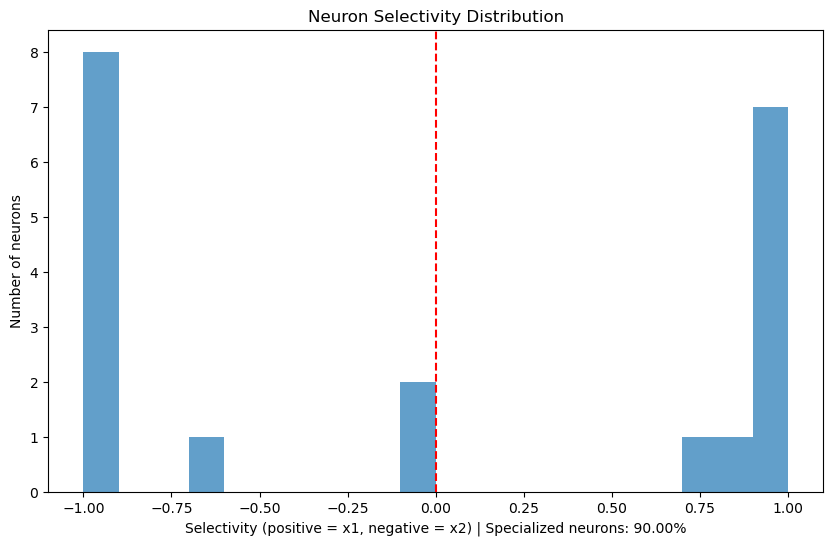

{'between_distance': 1.606107234954834, 'within_variance': 0.14777785539627075, 'separation_ratio': 4.178013801574707, 'specialized_score': 0.8999999761581421}


<Figure size 640x480 with 0 Axes>

In [98]:
from src.ce_exp import * 

# visualize_representations(mlp, valset, batch_size=32)
# visualize_representations_umap(mlp, valset, batch_size=32)
# visualize_representations_tsne(mlp, valset, batch_size=32)
separation_metrics = measure_separation(mlp, valset, batch_size=32)
specialized_score = neuron_specialization(mlp, valset, batch_size=32, save_path="logs/exp_a4_neuron_specialization.png")
separation_metrics['specialized_score'] = specialized_score
print(separation_metrics)

In [5]:
from PIL import Image
import os

# Paths to the GIF files
gif1_path = 'logs/exp_a7_neuron_specialization.gif'
gif2_path = 'logs/exp_a8_neuron_specialization.gif'
output_path = 'logs/combined_neuron_specialization.gif'

# Load the GIFs
gif1 = Image.open(gif1_path)
gif2 = Image.open(gif2_path)

# Get the number of frames in each GIF
def get_frame_count(gif):
    frames = 0
    try:
        while True:
            gif.seek(frames)
            frames += 1
    except EOFError:
        pass
    gif.seek(0)  # Reset to first frame
    return frames

n_frames1 = get_frame_count(gif1)
n_frames2 = get_frame_count(gif2)

# Use the minimum number of frames between the two GIFs
n_frames = min(n_frames1, n_frames2)

# Create new frames by combining images side by side
combined_frames = []
for i in range(n_frames):
    # Get current frames
    gif1.seek(i)
    gif2.seek(i)
    frame1 = gif1.copy().convert('RGBA')
    frame2 = gif2.copy().convert('RGBA')
    
    # Create a new image with enough width for both frames
    width = frame1.width + frame2.width
    height = max(frame1.height, frame2.height)
    combined = Image.new('RGBA', (width, height))
    
    # Paste the frames side by side
    combined.paste(frame1, (0, 0))
    combined.paste(frame2, (frame1.width, 0))
    
    combined_frames.append(combined)

# Save the combined GIF
fps = 4  # Use the same FPS as in your original code
duration = int(1000 / fps)  # Convert fps to duration in ms
combined_frames[0].save(
    output_path,
    save_all=True,
    append_images=combined_frames[1:],
    optimize=False,
    duration=duration,
    loop=0
)

print(f"Combined GIF saved to {output_path}")


Combined GIF saved to logs/combined_neuron_specialization.gif


In [2]:
import os 
import pickle 
from src.utils import plot_dual_metrics

log_dir = "logs"

plot_dual_metrics(loss_record, names=(f'l1_positive', f'l1_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_l1_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'mbe_positive', f'mbe_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_mbe_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'param_shift_cosine_similarity_positive', f'param_shift_cosine_similarity_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_param_shift_sim_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'rep_cosine_similarity_positive', f'rep_cosine_similarity_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_rep_sim_pos_neg.png"), same_scale=True)

# save loss record 
with open(os.path.join(log_dir, f"{exp_name}_loss_record.pkl"), "wb") as f: 
    pickle.dump(loss_record, f)

Plotting metrics: l1_positive and l1_negative...
Using same scale for both axes: [0.0262, 0.7365]
- Plot saved to logs/exp_a8_l1_pos_neg.png
Plotting metrics: mbe_positive and mbe_negative...
Using same scale for both axes: [0.0147, 0.3788]
- Plot saved to logs/exp_a8_mbe_pos_neg.png
Plotting metrics: param_shift_cosine_similarity_positive and param_shift_cosine_similarity_negative...
Using same scale for both axes: [-0.0295, 0.0295]
- Plot saved to logs/exp_a8_param_shift_sim_pos_neg.png
Plotting metrics: rep_cosine_similarity_positive and rep_cosine_similarity_negative...
Using same scale for both axes: [0.4110, 0.6349]
- Plot saved to logs/exp_a8_rep_sim_pos_neg.png


In [9]:
import os, glob 

log_dir = "logs"  # Change this to your directory path if needed

# Find all PNG files
png_files = glob.glob(os.path.join(log_dir, "*.png"))
exps = ["exp_a7", "exp_a8"]
png_files = [f for f in png_files if any(exp in f for exp in exps)]
png_files.sort()  # Sort them for consistent arrangement

idx = 3
png_files[idx::4]

['logs/exp_a7_rep_sim_pos_neg.png', 'logs/exp_a8_rep_sim_pos_neg.png']

In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
import glob

# Directory containing the plots
log_dir = "logs"  # Change this to your directory path if needed

# Find all PNG files
# png_files = glob.glob(os.path.join(log_dir, "*.png"))
# exps = ["exp_a1", "exp_a2"]
# png_files = [f for f in png_files if any(exp in f for exp in exps)]
# png_files.sort()  # Sort them for consistent arrangement
# idx = 3
png_files = png_files[idx::4]

if not png_files:
    print(f"No PNG files found in {log_dir}")
else:
    # Calculate grid size based on number of images
    n_images = len(png_files)
    n_cols = min(2, n_images)  # Maximum 3 columns
    n_rows = (n_images + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure and subplots
    fig = plt.figure(figsize=(n_cols * 6, n_rows * 5))
    
    # Add each image to the plot
    for i, png_file in enumerate(png_files):
        ax = fig.add_subplot(n_rows, n_cols, i+1)
        
        # Read image
        img = imread(png_file)
        ax.imshow(img)
        
        # Set title from filename (cleaned up)
        basename = os.path.basename(png_file)
        title = basename.replace('.png', '').replace('_', ' ')
        ax.set_title(title)
        
        # Remove axes for cleaner look
        ax.axis('off')
    
    # Adjust spacing
    plt.tight_layout()
    
    # Save combined figure
    combined_path = os.path.join(log_dir, "combined_plots.png")
    plt.savefig(combined_path, dpi=150, bbox_inches='tight')
    print(f"Combined plot saved at: {combined_path}")
    
    # Show the figure
    plt.show()

NameError: name 'png_files' is not defined

In [ ]:
# Experiment (I). Positive dataset training --> increase in parameter shift similarity with positive param shift. 
# Experiment (II). 

In [ ]:
# Get weight in MLP param 

# Sample a bunch of input samples 

# 1. Data preparation 
# Design a "shift" in the param space 
# - Apply shift to param, use resulting model to get output (targets) for all inputs 
# - Revert that 'shift' (Or just rotate it with near 180 degree) to obtain 'negative samples'
# This would give us a pair of datasets, which is nagatively aligned with each other in its 'loss's gradient over parameter'
# loss should be simple L1 loss

# 2. Training
# - Train with A, then B. 
# - Train with B, then A. 
# - Interleaved Training (A->B->A->B... or even just mix A & B together etc ...)
# - PGS-enhanced MBE regularization (Algo 3.a)
# - PBRS (Algo 3.c)
# - Phase transition (Algo 3.b)


# 3. Evaluation
# 1. L1 loss
# 2. MBE loss 
# 3. Gradient conflicts? (Intermediate gradient conflict, if we could observe it after 'resolving conflicting' in compression phase would be nice)
